Alzheimer's Disease Diagnosis - Machine Learning Pipeline 
Target Variable: Diagnosis ( 0 = No Alzheimer's, 1 = Alzheimer's)

In [1]:
# Core Imports
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#sklearn Imports 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "Times New Roman",
    }
)

print("Libraries imported successfully!")

Libraries imported successfully!


1. Load & Preview Data

In [2]:
df = pd.read_csv("../datasets/alzheimers_disease_data.csv")

df.drop(columns=["PatientID", "DoctorInCharge"], inplace=True)

print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 2,149 rows, 33 columns


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


2. Exploratory Data Analysis (EDA)

In [10]:
print("Data types & Non-Null counts:")
df.info()
print()
print("Missing Values:")
print(df.isnull().sum().sum(), "total missing values")
print()
print("Statistical Summary:")
df.describe().round(2)


Data types & Non-Null counts:
<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 21

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.00,2149.00,2149.0,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,...,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00,2149.00
mean,74.91,0.51,0.7,1.29,27.66,0.29,10.04,4.92,4.99,7.05,...,5.08,0.21,0.16,4.98,0.21,0.16,0.15,0.16,0.30,0.35
std,8.99,0.50,1.0,0.90,7.22,0.45,5.76,2.86,2.91,1.76,...,2.89,0.41,0.36,2.95,0.40,0.37,0.36,0.37,0.46,0.48
min,60.00,0.00,0.0,0.00,15.01,0.00,0.00,0.00,0.01,4.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,67.00,0.00,0.0,1.00,21.61,0.00,5.14,2.57,2.46,5.48,...,2.57,0.00,0.00,2.34,0.00,0.00,0.00,0.00,0.00,0.00
50%,75.00,1.00,0.0,1.00,27.82,0.00,9.93,4.77,5.08,7.12,...,5.09,0.00,0.00,5.04,0.00,0.00,0.00,0.00,0.00,0.00
75%,83.00,1.00,1.0,2.00,33.87,1.00,15.16,7.43,7.56,8.56,...,7.55,0.00,0.00,7.58,0.00,0.00,0.00,0.00,1.00,1.00
max,90.00,1.00,3.0,3.00,39.99,1.00,19.99,9.99,10.00,10.00,...,10.00,1.00,1.00,10.00,1.00,1.00,1.00,1.00,1.00,1.00


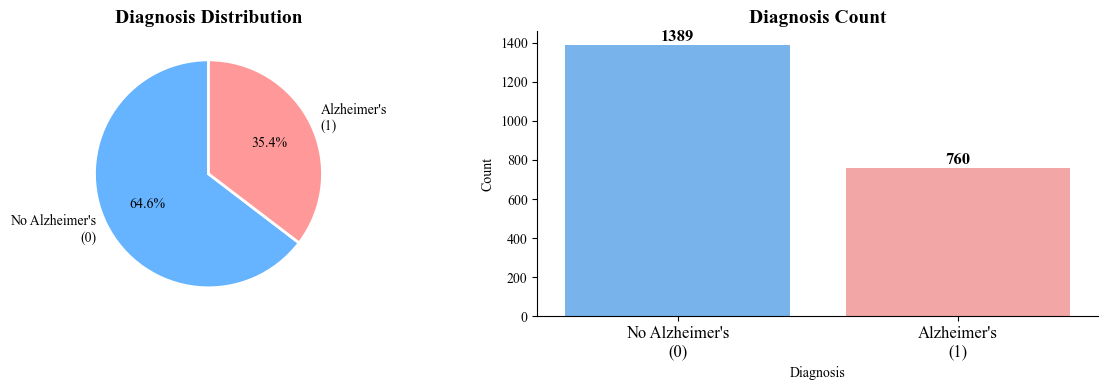

class ratio: 1.83 (No Alzheimer's : Alzheimer's)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#pie chart
counts = df["Diagnosis"].value_counts()
axes[0].pie(counts, labels=["No Alzheimer's\n(0)", "Alzheimer's\n(1)"],
             autopct="%1.1f%%", colors=["#66b3ff", "#ff9999"],
             startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Diagnosis Distribution", fontsize=14, fontweight="bold")

#bar chart
sns.countplot(data=df, x="Diagnosis", palette=["#66b3ff", "#ff9999"], ax=axes[1])
axes[1].set_xticklabels(["No Alzheimer's\n(0)", "Alzheimer's\n(1)"], fontsize=12)
axes[1].set_title("Diagnosis Count", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Diagnosis")
axes[1].set_ylabel("Count")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'class ratio: {counts[0] / counts[1]:.2f} (No Alzheimer\'s : Alzheimer\'s)')